In [1]:
import sys, os
_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))  # scrape_code/
sys.path.insert(0, os.path.join(_ROOT, 'utils'))

In [2]:
import pandas as pd 
import requests 
import numpy as np 
import json, os, time, pdb 

import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme() 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve, brier_score_loss

import statsmodels.api as sm 

from util_data_funcs import *


def save_graph_fig(ax_input, filename):
    fig = ax_input.get_figure()
    fig.savefig(filename, dpi=300, bbox_inches='tight')


def get_winner(df):
    if df['home_team_score'] > df['away_team_score']:
        return df['home_team'], 'home'
    elif df['home_team_score'] < df['away_team_score']:
        return df['away_team'], 'away'
    else:
        return 'Tie', 'Tie'
    

def format_score_diff_feats(df):
    df[['winning_team', 'winning_side']] = df.apply(get_winner, axis=1, result_type='expand')
    df['score_diff'] = np.abs(df['home_team_score'] - df['away_team_score'])
    return df 


def add_per_game_metrics(input_df):
    checker = input_df.groupby('league_season')[
        ['home_yellow_cards', 'away_yellow_cards', 'home_red_cards', 'away_red_cards']
    ].sum().reset_index().merge(
        input_df.groupby('league_season')['game_id'].nunique().reset_index(), 
        on='league_season', 
        how='left'
    )

    checker['total_yc'] = checker['home_yellow_cards'] + checker['away_yellow_cards']
    checker['total_rc'] = checker['home_red_cards'] + checker['away_red_cards']

    checker['yc_per_game'] = checker['total_yc'] / checker['game_id']
    checker['rc_per_game'] = checker['total_rc'] / checker['game_id']

    checker['home_yc_per_game'] = checker['home_yellow_cards'] / checker['game_id']
    checker['away_yc_per_game'] = checker['away_yellow_cards'] / checker['game_id']

    checker['home_rc_per_game'] = checker['home_red_cards'] / checker['game_id']
    checker['away_rc_per_game'] = checker['away_red_cards'] / checker['game_id']

    return checker 


def get_game_quarters(df):
    q_val = 'first_half'
    if df['Time'] <= 40:
        return q_val
    elif df['Time'] > 40 and df['Time'] <= 60:
        return 'third_quarter'
    elif df['Time'] > 60:
        return 'fourth_quarter'
    else:
        q_val


def get_match_time_metrics(df, event_name, col_name):

    df.loc[(df['game_period'] == 'fourth_quarter') & (df['Event_Type'] == event_name), 'Last_20_{}'.format(col_name)] = df['Player']
    df.loc[(df['game_period'] != 'fourth_quarter') | (df['Event_Type'] != event_name), 'Last_20_{}'.format(col_name)] = 0

    df.loc[(df['game_period'] == 'third_quarter') & (df['Event_Type'] == event_name), 'Q3_{}'.format(col_name)] = df['Player']
    df.loc[(df['game_period'] != 'third_quarter') | (df['Event_Type'] != event_name), 'Q3_{}'.format(col_name)] = 0

    df.loc[(df['game_period'] == 'first_half') & (df['Event_Type'] == event_name), 'H1_{}'.format(col_name)] = df['Player']
    df.loc[(df['game_period'] != 'first_half') | (df['Event_Type'] != event_name), 'H1_{}'.format(col_name)] = 0

    return df 




t14_game_df, t14_player_df, t14_team_df = gather_dataframes('T14')
urc_game_df, urc_player_df, urc_team_df = gather_dataframes('URC')
prem_game_df, prem_player_df, prem_team_df = gather_dataframes('Prem')
champ_cup_game_df, champ_cup_player_df = gather_dataframes('ChampCup')
# sr_game_df, sr_player_df, sr_team_df = gather_dataframes('SR')
six_nat_game_df, six_nat_player_df, six_nat_team_df = gather_dataframes('SixNat')
# rchamp_game_df, rchamp_player_df, rchamp_team_df = gather_dataframes('RChamp')

/home/colingrosh/Desktop/sports_analytics/code/rugby_v2/Rugby_DB_Analysis/scrape_code/utils/util_data_funcs.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grab_files = lambda league, order: pd.concat(list(map(pd.read_csv, league_dict[league][order])))
/home/colingrosh/Desktop/sports_analytics/code/rugby_v2/Rugby_DB_Analysis/scrape_code/utils/util_data_funcs.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grab_files = lambda league, order: pd.concat(list(map(pd.read_csv, league_dict[le

In [3]:
total_club_df = pd.concat(
    [urc_game_df, t14_game_df, prem_game_df, champ_cup_game_df]
    # [t14_game_df, prem_game_df]
)

total_club_df = format_score_diff_feats(total_club_df)

In [4]:
f_path = '../../formed_data/archive/team_data_v2'
old_team_data = [f_path+'/'+i for i in os.listdir(f_path)]
old_team_df = pd.concat(list(map(pd.read_csv, old_team_data)))
old_team_df.drop('Unnamed: 0', axis=1, inplace=True)

team_info_df = pd.concat(
    [urc_team_df, t14_team_df, prem_team_df]
    # [t14_game_df, prem_game_df]
)

comb_team_info = pd.concat([team_info_df, old_team_df])
comb_team_info

,team_name,team_link,team_id,rank,season,league_id,Unnamed: 0,ranking,team_abbr,Team
0,Leinster,/rugby/team/_/id/25924/leinster,25924.0,1.0,2020,270557.0,NaN,NaN,NaN,NaN
1,Ulster,/rugby/team/_/id/25926/ulster,25926.0,2.0,2020,270557.0,NaN,NaN,NaN,NaN
2,Glasgow Warriors,/rugby/team/_/id/25952/glasgow-warriors,25952.0,3.0,2020,270557.0,NaN,NaN,NaN,NaN
3,Cheetahs,/rugby/team/_/id/25955/cheetahs,25955.0,4.0,2020,270557.0,NaN,NaN,NaN,NaN
4,Dragons,/rugby/team/_/id/25967/dragons,25967.0,5.0,2020,270557.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7,Sale Sharks,NaN,NaN,8.0,2018,267979.0,NaN,NaN,SAL,NaN
8,Northampton Saints,NaN,NaN,9.0,2018,267979.0,NaN,NaN,NOR,NaN
9,Harlequins,NaN,NaN,10.0,2018,267979.0,NaN,NaN,HAR,NaN
10,Worcester Warriors,NaN,NaN,11.0,2018,267979.0,NaN,NaN,WORCS,NaN


In [5]:
match_comm_path = '../../formed_data/match_comm_data'
comm_files = [match_comm_path+'/'+i for i in os.listdir(match_comm_path) if '_v2' in i]
comm_df = pd.concat(list(map(pd.read_csv, comm_files)))

comm_df = comm_df.drop_duplicates().reset_index(drop=True)
comm_df['game_period'] = comm_df.apply(get_game_quarters, axis=1)

In [6]:
comm_df

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period
0,597160,271937,82,Sale Sharks,Robert du Preez,Conversion,37.0,27.0,fourth_quarter
1,597160,271937,81,Sale Sharks,Tom Curtis,Try,37.0,25.0,fourth_quarter
2,597160,271937,80,Leinster,Charlie Ngatai,Sub_Out,37.0,20.0,fourth_quarter
3,597160,271937,80,Sale Sharks,Robert du Preez,Conversion,37.0,20.0,fourth_quarter
4,597160,271937,79,Sale Sharks,Tommy Taylor,Try,37.0,18.0,fourth_quarter
...,...,...,...,...,...,...,...,...,...
264066,290537,270557,30,Zebre,Derick Minnie,Try,13.0,7.0,first_half
264067,290537,270557,14,Zebre,Federico Ruzza,Try,8.0,7.0,first_half
264068,290537,270557,8,Dragons,Angus O'Brien,Conversion,3.0,7.0,first_half
264069,290537,270557,7,Dragons,Cory Hill,Try,3.0,5.0,first_half


In [7]:
rc_comm_df = comm_df[(comm_df['Event_Type'].isin(['Red_Card', 'Yellow_Card']))].reset_index(drop=True)
rc_comm_df

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period
0,597160,271937,78,Leinster,Hugo Keenan,Yellow_Card,37.0,13.0,fourth_quarter
1,597160,271937,37,Sale Sharks,James Harper,Yellow_Card,6.0,13.0,first_half
2,597160,271937,3,Leinster,Robbie Henshaw,Yellow_Card,NaN,NaN,first_half
3,597151,271937,12,La Rochelle,Jonathan Danty,Yellow_Card,3.0,0.0,first_half
4,597151,271937,12,Leinster,Joe McCarthy,Yellow_Card,3.0,0.0,first_half
...,...,...,...,...,...,...,...,...,...
7016,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter
7017,290555,270557,75,Benetton Treviso,Tiziano Pasquali,Yellow_Card,3.0,19.0,fourth_quarter
7018,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half
7019,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half


In [8]:
first_card_df = rc_comm_df.groupby(['game_id', 'Team', 'Event_Type'])['Time'].min().reset_index()
first_card_df['first_card_flag'] = 1
display(first_card_df.head())

rc_comm_flag_df = rc_comm_df.merge(first_card_df, how='left', on=['game_id', 'Team', 'Time', 'Event_Type'])
rc_comm_flag_df.loc[rc_comm_flag_df['first_card_flag'].isnull(), 'first_card_flag'] = 0
display(rc_comm_flag_df)

,game_id,Team,Event_Type,Time,first_card_flag
0,118673,Exeter Chiefs,Yellow_Card,59,1
1,118681,London Irish,Yellow_Card,56,1
2,118683,Harlequins,Yellow_Card,39,1
3,118685,Yorkshire Carnegie,Yellow_Card,27,1
4,118686,Exeter Chiefs,Yellow_Card,39,1


,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597160,271937,78,Leinster,Hugo Keenan,Yellow_Card,37.0,13.0,fourth_quarter,0.0
1,597160,271937,37,Sale Sharks,James Harper,Yellow_Card,6.0,13.0,first_half,1.0
2,597160,271937,3,Leinster,Robbie Henshaw,Yellow_Card,NaN,NaN,first_half,1.0
3,597151,271937,12,La Rochelle,Jonathan Danty,Yellow_Card,3.0,0.0,first_half,1.0
4,597151,271937,12,Leinster,Joe McCarthy,Yellow_Card,3.0,0.0,first_half,1.0
...,...,...,...,...,...,...,...,...,...,...
7016,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0
7017,290555,270557,75,Benetton Treviso,Tiziano Pasquali,Yellow_Card,3.0,19.0,fourth_quarter,0.0
7018,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0
7019,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0


In [9]:
rc_game_total = total_club_df[total_club_df['game_id'].isin(first_card_df['game_id'].unique())]
rc_game_total

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,237369,271937,Montpellier Herault,27,Stade Toulousain,26,2.0,2.0,1.0,2.0,...,4.0,1.00,10.0,12.0,0.83,2015-01-25,2014-2015,Montpellier Herault,home,1
62,237347,271937,Glasgow Warriors,21,Montpellier Herault,10,3.0,1.0,3.0,1.0,...,7.0,0.71,12.0,13.0,0.92,2015-01-18,2014-2015,Glasgow Warriors,home,11
63,237373,271937,Northampton Saints,8,Racing 92,32,1.0,4.0,0.0,3.0,...,8.0,1.00,8.0,8.0,1.00,2015-01-24,2014-2015,Racing 92,away,24
64,237353,271937,Racing 92,53,Benetton Treviso,7,8.0,1.0,4.0,1.0,...,7.0,1.00,10.0,15.0,0.66,2015-01-18,2014-2015,Racing 92,home,46


In [10]:
rc_comm_filt = rc_comm_flag_df[rc_comm_flag_df['first_card_flag'] == 1].reset_index(drop=True)
rc_comm_filt[['Home_Score', 'Away_Score']] = rc_comm_filt[['Home_Score', 'Away_Score']].fillna(0.0)
rc_comm_filt

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597160,271937,37,Sale Sharks,James Harper,Yellow_Card,6.0,13.0,first_half,1.0
1,597160,271937,3,Leinster,Robbie Henshaw,Yellow_Card,0.0,0.0,first_half,1.0
2,597151,271937,12,La Rochelle,Jonathan Danty,Yellow_Card,3.0,0.0,first_half,1.0
3,597151,271937,12,Leinster,Joe McCarthy,Yellow_Card,3.0,0.0,first_half,1.0
4,597144,271937,30,Toulon,Brian Alainu'uese,Yellow_Card,12.0,5.0,first_half,1.0
...,...,...,...,...,...,...,...,...,...,...
5540,290547,270557,72,Dragons,Charlie Davies,Yellow_Card,3.0,20.0,fourth_quarter,1.0
5541,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0
5542,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0
5543,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0


In [11]:
rc_game_total.head()

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37


In [12]:
rc_comm_filt.head()

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597160,271937,37,Sale Sharks,James Harper,Yellow_Card,6.0,13.0,first_half,1.0
1,597160,271937,3,Leinster,Robbie Henshaw,Yellow_Card,0.0,0.0,first_half,1.0
2,597151,271937,12,La Rochelle,Jonathan Danty,Yellow_Card,3.0,0.0,first_half,1.0
3,597151,271937,12,Leinster,Joe McCarthy,Yellow_Card,3.0,0.0,first_half,1.0
4,597144,271937,30,Toulon,Brian Alainu'uese,Yellow_Card,12.0,5.0,first_half,1.0


In [13]:
games_yc = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card']['game_id'].unique())
][['game_id', 'league_id', 'league_season', 'season']].drop_duplicates()

games_rc = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card']['game_id'].unique())
][['game_id', 'league_id', 'league_season', 'season']].drop_duplicates()

games_cards = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'].isin(['Red_Card', 'Yellow_Card'])]['game_id'].unique())
][['game_id', 'league_id', 'league_season', 'season']].drop_duplicates()


In [14]:
rc_game_total[rc_game_total['game_id'] == 290556]

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
82,290556,270557,Leinster,15,Scarlets,27,2.0,3.0,1.0,3.0,...,12.0,1.0,11.0,13.0,0.84,2017-05-19,2016-2017,Scarlets,away,12


In [15]:
rc_comm_filt[rc_comm_filt['game_id'] == 290556]

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
5508,290556,270557,38,Scarlets,Steffan Evans,Red_Card,10.0,21.0,first_half,1.0


## Single Game Case Studies 


### Identifying other good example cases with many cards 
### What makes a good case study example
#### - More than one card possibly 
#### - Both teams incurring a card 
#### - A team incurring a card and still winning 
#### - Games with cards in both halves 
#### - Sample of pre and post 2017

In [23]:
rc_game_total.columns

Index(['game_id', 'league_id', 'home_team', 'home_team_score', 'away_team',
       'away_team_score', 'home_tries', 'away_tries', 'home_conversions',
       'away_conversions', 'home_penalty_goals', 'away_penalty_goals',
       'home_kick_percent', 'away_kick_percent', 'home_total_meters',
       'away_total_meters', 'home_kfh', 'away_kfh', 'home_pass_meters',
       'away_pass_meters', 'home_runs', 'away_runs', 'home_possession_1h_2h',
       'home_territory_1h_2h', 'home_clean_breaks', 'home_defenders_beaten',
       'home_offloads', 'home_rucks_won', 'home_mauls_won',
       'home_turnovers_conceeded', 'away_possession_1h_2h',
       'away_territory_1h_2h', 'away_clean_breaks', 'away_defenders_beaten',
       'away_offloads', 'away_rucks_won', 'away_mauls_won',
       'away_turnovers_conceeded', 'home_total_possession',
       'home_total_territory', 'away_total_possesion', 'away_total_territory',
       'home_scrum', 'home_lineout', 'away_scrum', 'away_lineout',
       'home_tackle

In [29]:
check_games = rc_game_total[
    (rc_game_total['home_yellow_cards'] >= 1) |
    (rc_game_total['away_yellow_cards'] >= 1) | 
    (rc_game_total['home_red_cards'] >= 1) |
    (rc_game_total['away_red_cards'] >= 1)
][[
    'game_id', 'league_id', 'home_team', 
    'away_team', 'home_team_score', 'away_team_score', 
    'home_yellow_cards', 'away_yellow_cards', 
    'home_red_cards', 'away_red_cards',
    'league_season','date_formatted'
]].sort_values(
    by=['league_id', 'date_formatted']
)

check_games

,game_id,league_id,home_team,away_team,home_team_score,away_team_score,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,league_season,date_formatted
43,118683,267979,Northampton Saints,Harlequins,13,16,0.0,2.0,0.0,0.0,2010-2011,2011-01-01
52,118681,267979,London Irish,Bath Rugby,24,25,1.0,0.0,0.0,0.0,2010-2011,2011-01-01
72,118689,267979,Newcastle Falcons,Sale Sharks,19,19,1.0,0.0,0.0,0.0,2010-2011,2011-01-07
11,118688,267979,Leicester Tigers,Northampton Saints,27,16,0.0,1.0,0.0,0.0,2010-2011,2011-01-08
33,118686,267979,Gloucester Rugby,Exeter Chiefs,37,23,0.0,1.0,0.0,0.0,2010-2011,2011-01-08
...,...,...,...,...,...,...,...,...,...,...,...,...
23,597160,271937,Leinster,Sale Sharks,37,27,2.0,1.0,0.0,0.0,2023-2024,2023-12-16
24,597160,271937,Leinster,Sale Sharks,37,27,2.0,1.0,0.0,0.0,2023-2024,2023-12-16
25,597160,271937,Leinster,Sale Sharks,37,27,2.0,1.0,0.0,0.0,2023-2024,2023-12-16
9,597164,271937,Harlequins,Stade Toulousain,19,47,0.0,1.0,0.0,0.0,2023-2024,2023-12-17


In [30]:
check_games[check_games['league_season'] == '2015-2016']

,game_id,league_id,home_team,away_team,home_team_score,away_team_score,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,league_season,date_formatted
12,267713,267979,Bath Rugby,Exeter Chiefs,19,17,2.0,0.0,0.0,0.0,2015-2016,2015-10-17
18,267717,267979,London Irish,Leicester Tigers,16,28,1.0,0.0,0.0,0.0,2015-2016,2015-10-18
5,267719,267979,Northampton Saints,Newcastle Falcons,42,16,0.0,1.0,0.0,0.0,2015-2016,2015-10-24
11,267721,267979,Wasps,Bath Rugby,16,9,0.0,1.0,0.0,0.0,2015-2016,2015-10-24
17,267727,267979,Leicester Tigers,Harlequins,22,19,1.0,0.0,0.0,0.0,2015-2016,2015-10-25
...,...,...,...,...,...,...,...,...,...,...,...,...
19,271481,271937,Stade Toulousain,Ulster,23,25,0.0,1.0,0.0,0.0,2015-2016,2015-12-20
59,271443,271937,Stade Francais Paris,Munster,27,7,0.0,0.0,1.0,0.0,2015-2016,2016-01-09
45,271511,271937,Clermont Auvergne,Bordeaux Begles,28,37,0.0,1.0,0.0,0.0,2015-2016,2016-01-24
36,271527,271937,Saracens,Northampton Saints,29,20,1.0,0.0,0.0,0.0,2015-2016,2016-04-09


In [31]:
check_games[check_games['league_season'] == '2018-2019']

,game_id,league_id,home_team,away_team,home_team_score,away_team_score,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,league_season,date_formatted
29,293395,267979,Worcester Warriors,Wasps,20,21,1.0,0.0,0.0,0.0,2018-2019,2018-09-01
54,293393,267979,Gloucester Rugby,Northampton Saints,27,16,2.0,0.0,0.0,0.0,2018-2019,2018-09-01
20,293397,267979,Newcastle Falcons,Saracens,21,32,0.0,2.0,0.0,0.0,2018-2019,2018-09-02
19,293401,267979,Saracens,Bristol Rugby,44,23,0.0,0.0,0.0,1.0,2018-2019,2018-09-08
37,293400,267979,Leicester Tigers,Newcastle Falcons,49,33,1.0,0.0,0.0,0.0,2018-2019,2018-09-08
...,...,...,...,...,...,...,...,...,...,...,...,...
46,293625,271937,Edinburgh,Munster,13,17,0.0,1.0,0.0,0.0,2018-2019,2019-03-30
42,293627,271937,Racing 92,Stade Toulousain,21,22,2.0,0.0,0.0,1.0,2018-2019,2019-03-31
45,293628,271937,Saracens,Munster,32,16,1.0,0.0,0.0,0.0,2018-2019,2019-04-20
38,293629,271937,Leinster,Stade Toulousain,30,12,1.0,1.0,0.0,0.0,2018-2019,2019-04-21


In [32]:
check_games[check_games['league_season'] == '2021-2022']

,game_id,league_id,home_team,away_team,home_team_score,away_team_score,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,league_season,date_formatted
19,593836,267979,Leicester Tigers,Exeter Chiefs,34,19,1.0,0.0,0.0,0.0,2021-2022,2021-09-18
28,593838,267979,Sale Sharks,Bath Rugby,20,19,1.0,0.0,0.0,0.0,2021-2022,2021-09-18
42,593837,267979,Northampton Saints,Gloucester Rugby,34,20,1.0,2.0,0.0,0.0,2021-2022,2021-09-18
60,593839,267979,Worcester Warriors,London Irish,36,24,0.0,1.0,0.0,0.0,2021-2022,2021-09-18
47,593841,267979,Gloucester Rugby,Leicester Tigers,26,33,1.0,1.0,0.0,0.0,2021-2022,2021-09-24
...,...,...,...,...,...,...,...,...,...,...,...,...
57,594215,270559,Lyon,La Rochelle,26,29,0.0,1.0,0.0,0.0,2021-2022,2022-06-05
67,594216,270559,Racing 92,Toulon,21,16,0.0,1.0,0.0,0.0,2021-2022,2022-06-05
104,594218,270559,Stade Francais Paris,Brive,17,33,1.0,0.0,0.0,0.0,2021-2022,2022-06-05
1,594223,270559,Castres Olympique,Stade Toulousain,24,18,0.0,2.0,0.0,0.0,2021-2022,2022-06-17


### Scarlets vs Leinster 2017 Semi Final 

In [16]:
urc_card_games = games_cards[games_cards['league_id'] == 270557] 
urc_card_df = rc_game_total[
    (rc_game_total['league_id'] == 270557) & 
    (rc_game_total['game_id'].isin(urc_card_games['game_id'].unique()))
]
display(urc_card_games.head())
display(urc_card_df.head())

,game_id,league_id,league_season,season
1,167046,270557,2012-2013,2012
2,167039,270557,2012-2013,2012
3,167035,270557,2012-2013,2012
4,167027,270557,2012-2013,2012
5,167020,270557,2012-2013,2012


,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37


In [17]:
cs_1_df = urc_game_df[urc_game_df['date_formatted'] == '2017-05-19']
cs_1_comm_df = comm_df[comm_df['game_id'] == cs_1_df['game_id'].iloc[0]]

In [18]:
cs_1_df.head()

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_mauls_won_total_num,away_mauls_won_percent,away_scrum_num,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season
82,290556,270557,Leinster,15,Scarlets,27,2.0,3.0,1.0,3.0,...,4.0,0.5,12.0,12.0,1.0,11.0,13.0,0.84,2017-05-19,2016-2017


In [19]:
home_away_df = cs_1_df[[
    'game_id', 'league_id', 'home_team', 'away_team', 'home_team_score', 'away_team_score', 
    'home_1h_poss', 'home_2h_poss', 'away_1h_poss', 'away_2h_poss', 
    'home_1h_terr', 'home_2h_terr', 'away_1h_terr', 'away_2h_terr']]
home_away_df

,game_id,league_id,home_team,away_team,home_team_score,away_team_score,home_1h_poss,home_2h_poss,away_1h_poss,away_2h_poss,home_1h_terr,home_2h_terr,away_1h_terr,away_2h_terr
82,290556,270557,Leinster,Scarlets,15,27,0.61,0.63,0.39,0.37,0.64,0.66,0.36,0.34


In [20]:
cs_comm_form = cs_1_comm_df.merge(home_away_df, how='left', on=['game_id', 'league_id'])
cs_comm_form['side'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], 'home', 'away')

cs_comm_form['team_final_score'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_team_score'], cs_comm_form['away_team_score'])
cs_comm_form['opp_final_score'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_team_score'], cs_comm_form['away_team_score'])

cs_comm_form['team_1h_poss'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_1h_poss'], cs_comm_form['away_1h_poss'])
cs_comm_form['team_2h_poss'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_2h_poss'], cs_comm_form['away_2h_poss'])

cs_comm_form['opp_1h_poss'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_1h_poss'], cs_comm_form['away_1h_poss'])
cs_comm_form['opp_2h_poss'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_2h_poss'], cs_comm_form['away_2h_poss'])

cs_comm_form['team_1h_terr'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_1h_terr'], cs_comm_form['away_1h_terr'])
cs_comm_form['team_2h_terr'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_2h_poss'], cs_comm_form['away_2h_terr'])

cs_comm_form['opp_1h_terr'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_1h_terr'], cs_comm_form['away_1h_terr'])
cs_comm_form['opp_2h_terr'] = np.where(cs_comm_form['Team'] == cs_comm_form['home_team'], cs_comm_form['home_2h_terr'], cs_comm_form['away_2h_terr'])

cs_comm_form

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,home_team,...,team_final_score,opp_final_score,team_1h_poss,team_2h_poss,opp_1h_poss,opp_2h_poss,team_1h_terr,team_2h_terr,opp_1h_terr,opp_2h_terr
0,290556,270557,80,Scarlets,DTH Van Der Merwe,Sub_In,15.0,27.0,fourth_quarter,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34
1,290556,270557,80,Scarlets,James Davies,Sub_Out,15.0,27.0,fourth_quarter,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34
2,290556,270557,80,Leinster,Ross Byrne,Sub_In,15.0,27.0,fourth_quarter,Leinster,...,15,15,0.61,0.63,0.61,0.63,0.64,0.63,0.64,0.66
3,290556,270557,80,Leinster,Johnny Sexton,Sub_Out,15.0,27.0,fourth_quarter,Leinster,...,15,15,0.61,0.63,0.61,0.63,0.64,0.63,0.64,0.66
4,290556,270557,80,Scarlets,Liam Williams,Penalty_Goal,15.0,27.0,fourth_quarter,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34
5,290556,270557,74,Leinster,Garry Ringrose,Sub_Out,15.0,24.0,fourth_quarter,Leinster,...,15,15,0.61,0.63,0.61,0.63,0.64,0.63,0.64,0.66
6,290556,270557,74,Leinster,Zane Kirchner,Sub_In,15.0,24.0,fourth_quarter,Leinster,...,15,15,0.61,0.63,0.61,0.63,0.64,0.63,0.64,0.66
7,290556,270557,71,Scarlets,Ryan Elias,Sub_Out,15.0,24.0,fourth_quarter,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34
8,290556,270557,71,Scarlets,Emyr Phillips,Sub_In,15.0,24.0,fourth_quarter,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34
9,290556,270557,71,Leinster,James Tracy,Sub_Out,15.0,24.0,fourth_quarter,Leinster,...,15,15,0.61,0.63,0.61,0.63,0.64,0.63,0.64,0.66


In [21]:
card_event = cs_comm_form[cs_comm_form['Event_Type'].isin(['Yellow_Card', 'Red_Card'])]
card_event

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,home_team,...,team_final_score,opp_final_score,team_1h_poss,team_2h_poss,opp_1h_poss,opp_2h_poss,team_1h_terr,team_2h_terr,opp_1h_terr,opp_2h_terr
31,290556,270557,38,Scarlets,Steffan Evans,Red_Card,10.0,21.0,first_half,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34


In [ ]:
df.loc[(df['game_period'] != 'fourth_quarter') | (df['Event_Type'] != event_name), 'Last_20_{}'.format(col_name)] = 0

In [22]:
card_event['side'].iloc[0].capitalize()

'Away'

In [23]:
card_event['side'].iloc[0]

'away'

In [27]:
card_event.iloc[0]

game_id                    290556
league_id                  270557
Time                           38
Team                     Scarlets
Player              Steffan Evans
Event_Type               Red_Card
Home_Score                   10.0
Away_Score                   21.0
game_period            first_half
home_team                Leinster
away_team                Scarlets
home_team_score                15
away_team_score                27
home_1h_poss                 0.61
home_2h_poss                 0.63
away_1h_poss                 0.39
away_2h_poss                 0.37
home_1h_terr                 0.64
home_2h_terr                 0.66
away_1h_terr                 0.36
away_2h_terr                 0.34
side                         away
team_final_score               27
opp_final_score                27
team_1h_poss                 0.39
team_2h_poss                 0.37
opp_1h_poss                  0.39
opp_2h_poss                  0.37
team_1h_terr                 0.36
team_2h_terr  

In [28]:
38/80

0.475

In [26]:
1 - (card_event['Time'].iloc[0] / 80)

np.float64(0.525)

In [26]:
comm_df['game_period'].unique()

array(['fourth_quarter', 'third_quarter', 'first_half'], dtype=object)

In [26]:
card_event.columns

Index(['game_id', 'league_id', 'Time', 'Team', 'Player', 'Event_Type',
       'Home_Score', 'Away_Score', 'game_period', 'home_team', 'away_team',
       'home_team_score', 'away_team_score', 'home_1h_poss', 'home_2h_poss',
       'away_1h_poss', 'away_2h_poss', 'home_1h_terr', 'home_2h_terr',
       'away_1h_terr', 'away_2h_terr', 'side', 'team_final_score',
       'opp_final_score', 'team_1h_poss', 'team_2h_poss', 'opp_1h_poss',
       'opp_2h_poss', 'team_1h_terr', 'team_2h_terr', 'opp_1h_terr',
       'opp_2h_terr'],
      dtype='object')

In [22]:
card_event.head()

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,home_team,...,team_final_score,opp_final_score,team_1h_poss,team_2h_poss,opp_1h_poss,opp_2h_poss,team_1h_terr,team_2h_terr,opp_1h_terr,opp_2h_terr
31,290556,270557,38,Scarlets,Steffan Evans,Red_Card,10.0,21.0,first_half,Leinster,...,27,27,0.39,0.37,0.39,0.37,0.36,0.34,0.36,0.34


In [ ]:
def get_post_card_impacts(df):

    team_side = df['side']
    if team_side == 'home':
        opp_side = 'away'
    else:
        opp_side = 'home'

    card_time = df['game_period']

    if card_time == 'first_half':

        # if team_side == 'home':
        terr_post_for = df[f'{team_side}_2h_terr']
        terr_post_against = df[f'{opp_side}_2h_terr']

        poss_pos_for = df[f'{team_side}_2h_poss']
        poss_post_against = df[f'{opp_side}_2h_poss']

        terr_diff_for = df[f'{team_side}_2h_terr'] - df[f'{team_side}_1h_terr']
        terr_diff_against = df[f'{opp_side}_2h_terr'] - df[f'{opp_side}_1h_terr']
        poss_diff_for = df[f'{team_side}_2h_poss'] - df[f'{team_side}_1h_poss']
        poss_diff_against = df[f'{opp_side}_2h_poss'] - df[f'{opp_side}_1h_poss']

    points_post_card = (df['team_final_score'] - df[f'{team_side.capitalize()}_Score'])
    
    return pd.Series({
        "points_post_card": points_post_card,
        "terr_post_card": terr_post_for,
        "terr_allowed_post_card": terr_post_against,
        "poss_post_card": poss_pos_for,
        "poss_allowed_post_card": poss_post_against,
        "terr_diff_for":,
        "terr_diff_against":, 
        "poss_diff_for":,
        "poss_diff_against":

    })



In [54]:
card_event.apply(get_post_card_impacts, axis=1)

,points_post_card,terr_post_card,terr_allowed_post_card,poss_post_card,poss_allowed_post_card
31,6.0,0.34,0.34,0.37,0.37


In [55]:
card_event.iloc[0]

game_id                    290556
league_id                  270557
Time                           38
Team                     Scarlets
Player              Steffan Evans
Event_Type               Red_Card
Home_Score                   10.0
Away_Score                   21.0
game_period            first_half
home_team                Leinster
away_team                Scarlets
home_team_score                15
away_team_score                27
home_1h_poss                 0.61
home_2h_poss                 0.63
away_1h_poss                 0.39
away_2h_poss                 0.37
home_1h_terr                 0.64
home_2h_terr                 0.66
away_1h_terr                 0.36
away_2h_terr                 0.34
side                         away
team_final_score               27
opp_final_score                27
team_1h_poss                 0.39
team_2h_poss                 0.37
opp_1h_poss                  0.39
opp_2h_poss                  0.37
team_1h_terr                 0.36
team_2h_terr  

In [47]:
card_event = cs_comm_form[cs_comm_form['Event_Type'].isin(['Yellow_Card', 'Red_Card'])]

if card_event['side'].iloc[0] == 'away':
    display(card_event['team_final_score'] - card_event['Away_Score'])

31    6.0
dtype: float64

In [33]:
cs_1_df[['home_team_score', 'away_team_score']]

,home_team_score,away_team_score
82,15,27


In [19]:
cs_1_df['away_1h_poss']

82    0.39
Name: away_1h_poss, dtype: float64

In [20]:
cs_1_df['away_2h_poss']

82    0.37
Name: away_2h_poss, dtype: float64

In [21]:
cs_1_df['home_1h_poss']

82    0.61
Name: home_1h_poss, dtype: float64

In [22]:
cs_1_df['home_2h_poss']

82    0.63
Name: home_2h_poss, dtype: float64

In [23]:
cs_1_df.columns

Index(['game_id', 'league_id', 'home_team', 'home_team_score', 'away_team',
       'away_team_score', 'home_tries', 'away_tries', 'home_conversions',
       'away_conversions', 'home_penalty_goals', 'away_penalty_goals',
       'home_kick_percent', 'away_kick_percent', 'home_total_meters',
       'away_total_meters', 'home_kfh', 'away_kfh', 'home_pass_meters',
       'away_pass_meters', 'home_runs', 'away_runs', 'home_possession_1h_2h',
       'home_territory_1h_2h', 'home_clean_breaks', 'home_defenders_beaten',
       'home_offloads', 'home_rucks_won', 'home_mauls_won',
       'home_turnovers_conceeded', 'away_possession_1h_2h',
       'away_territory_1h_2h', 'away_clean_breaks', 'away_defenders_beaten',
       'away_offloads', 'away_rucks_won', 'away_mauls_won',
       'away_turnovers_conceeded', 'home_total_possession',
       'home_total_territory', 'away_total_possesion', 'away_total_territory',
       'home_scrum', 'home_lineout', 'away_scrum', 'away_lineout',
       'home_tackle

In [24]:
cs_1_df

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_mauls_won_total_num,away_mauls_won_percent,away_scrum_num,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season
82,290556,270557,Leinster,15,Scarlets,27,2.0,3.0,1.0,3.0,...,4.0,0.5,12.0,12.0,1.0,11.0,13.0,0.84,2017-05-19,2016-2017


In [27]:
cs_1_comm_df[cs_1_comm_df['Event_Type'].isin(['Yellow_Card', 'Red_Card'])]

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period
261598,290556,270557,38,Scarlets,Steffan Evans,Red_Card,10.0,21.0,first_half


In [25]:
cs_1_comm_df

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period
261567,290556,270557,80,Scarlets,DTH Van Der Merwe,Sub_In,15.0,27.0,fourth_quarter
261568,290556,270557,80,Scarlets,James Davies,Sub_Out,15.0,27.0,fourth_quarter
261569,290556,270557,80,Leinster,Ross Byrne,Sub_In,15.0,27.0,fourth_quarter
261570,290556,270557,80,Leinster,Johnny Sexton,Sub_Out,15.0,27.0,fourth_quarter
261571,290556,270557,80,Scarlets,Liam Williams,Penalty_Goal,15.0,27.0,fourth_quarter
261572,290556,270557,74,Leinster,Garry Ringrose,Sub_Out,15.0,24.0,fourth_quarter
261573,290556,270557,74,Leinster,Zane Kirchner,Sub_In,15.0,24.0,fourth_quarter
261574,290556,270557,71,Scarlets,Ryan Elias,Sub_Out,15.0,24.0,fourth_quarter
261575,290556,270557,71,Scarlets,Emyr Phillips,Sub_In,15.0,24.0,fourth_quarter
261576,290556,270557,71,Leinster,James Tracy,Sub_Out,15.0,24.0,fourth_quarter


In [18]:
rc_comm_filt[rc_comm_filt['game_id'] == 290556]

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
5508,290556,270557,38,Scarlets,Steffan Evans,Red_Card,10.0,21.0,first_half,1.0


In [36]:
urc_yc_games[urc_yc_games['season'] > 2016]

,game_id,league_id,league_season,season
0,597988,270557,2023-2024,2023
1,597980,270557,2023-2024,2023
2,597971,270557,2023-2024,2023
3,597964,270557,2023-2024,2023
4,597957,270557,2023-2024,2023
...,...,...,...,...
139,290521,270557,2016-2017,2017
142,290547,270557,2016-2017,2017
144,290555,270557,2016-2017,2017
145,290496,270557,2016-2017,2017


In [ ]:
urc_yc_games[urc_yc_games['league_season'].isin([''])]

In [31]:
rc_game_total[rc_game_total['league_id'] == 270557]

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,290521,270557,Connacht,33,Zebre,3,4.0,0.0,4.0,0.0,...,13.0,1.00,12.0,17.0,0.70,2017-03-03,2016-2017,Connacht,home,30
142,290547,270557,Edinburgh,24,Dragons,20,3.0,2.0,3.0,2.0,...,5.0,1.00,15.0,16.0,0.93,2017-04-28,2016-2017,Edinburgh,home,4
144,290555,270557,Zebre,3,Benetton Treviso,19,0.0,1.0,0.0,1.0,...,13.0,0.92,11.0,12.0,0.91,2017-05-06,2016-2017,Benetton Treviso,away,16
145,290496,270557,Dragons,26,Benetton Treviso,8,2.0,1.0,2.0,0.0,...,6.0,1.00,14.0,17.0,0.82,2017-01-06,2016-2017,Dragons,home,18


In [30]:
rc_comm_filt[(rc_comm_filt['Event_Type'] == 'Yellow_Card') & (rc_comm_filt['league_id'] == 270557)]

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
4213,167046,270557,70,Ulster,Rory Best,Yellow_Card,20.0,12.0,fourth_quarter,1.0
4214,167039,270557,32,Zebre,Quintin Geldenhuys,Yellow_Card,10.0,0.0,first_half,1.0
4215,167035,270557,80,Leinster,Ian Madigan,Yellow_Card,0.0,6.0,fourth_quarter,1.0
4216,167035,270557,24,Glasgow Warriors,Tom Ryder,Yellow_Card,0.0,3.0,first_half,1.0
4217,167027,270557,51,Ospreys,Duncan Jones,Yellow_Card,9.0,10.0,third_quarter,1.0
...,...,...,...,...,...,...,...,...,...,...
5540,290547,270557,72,Dragons,Charlie Davies,Yellow_Card,3.0,20.0,fourth_quarter,1.0
5541,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0
5542,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0
5543,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0


In [21]:
games_rc[games_rc['league_id'] == 270557][['league_id', 'league_season']].value_counts().reset_index().sort_values(by=['league_id', 'league_season'])

,league_id,league_season,count
10,270557,2011-2012,2
7,270557,2012-2013,5
9,270557,2013-2014,3
1,270557,2014-2015,11
11,270557,2015-2016,2
6,270557,2016-2017,7
5,270557,2017-2018,8
3,270557,2018-2019,8
8,270557,2019-2020,5
2,270557,2020-2021,9


In [18]:
games_yc[games_yc['league_id'] == 270557][['league_id', 'league_season']].value_counts().reset_index().sort_values(by=['league_id', 'league_season'])

,league_id,league_season,count
10,270557,2010-2011,48
0,270557,2011-2012,100
2,270557,2012-2013,90
1,270557,2013-2014,91
4,270557,2014-2015,84
6,270557,2015-2016,75
7,270557,2016-2017,73
5,270557,2017-2018,80
8,270557,2018-2019,61
12,270557,2019-2020,19


In [17]:
games_yc[['league_id', 'league_season']].value_counts().reset_index().sort_values(by=['league_id', 'league_season'])

,league_id,league_season,count
42,267979,2010-2011,38
28,267979,2011-2012,70
21,267979,2012-2013,78
12,267979,2013-2014,97
16,267979,2014-2015,89
23,267979,2015-2016,75
27,267979,2016-2017,71
20,267979,2017-2018,79
24,267979,2018-2019,75
29,267979,2019-2020,66


In [15]:
games_yc['league_id'].value_counts()

league_id
270559    1390
267979    1061
270557     911
271937     416
Name: count, dtype: int64

In [16]:
yellow_total_base = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card']['game_id'].unique())
]

red_total_base = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card']['game_id'].unique())
]

yellow_score = yellow_total_base[
    [
        'game_id', 'league_id','league_season','home_team', 'away_team', 
        'home_team_score', 'away_team_score'
    ]
].merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'home_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_home_yellow')
).merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'away_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_away_yellow')
)


red_score = red_total_base[
    [
        'game_id', 'league_id','league_season','home_team', 'away_team', 
        'home_team_score', 'away_team_score'
    ]
].merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'home_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_home_red')
).merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'away_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_away_red')
)

# red_score_track = 

In [17]:
yellow_score = yellow_score[~yellow_score['Team'].isnull()].reset_index(drop=True)
red_score = red_score[~red_score['Team'].isnull()].reset_index(drop=True)

In [18]:
red_score['home_points_after_home_red'] = red_score['home_team_score'] - red_score['Home_Score']
red_score['away_points_after_home_red'] = red_score['away_team_score'] - red_score['Away_Score']

red_score['home_points_after_away_red'] = red_score['home_team_score'] - red_score['Home_Score_away_red']
red_score['away_points_after_away_red'] = red_score['away_team_score'] - red_score['Away_Score_away_red']

yellow_score['home_points_after_home_yellow'] = yellow_score['home_team_score'] - yellow_score['Home_Score']
yellow_score['away_points_after_home_yellow'] = yellow_score['away_team_score'] - yellow_score['Away_Score']

yellow_score['home_points_after_away_yellow'] = yellow_score['home_team_score'] - yellow_score['Home_Score_away_yellow']
yellow_score['away_points_after_away_yellow'] = yellow_score['away_team_score'] - yellow_score['Away_Score_away_yellow']



In [19]:
rc_game_total[rc_game_total['league_id'] == 267979]['league_season'].value_counts()

league_season
2020-2021    113
2021-2022    107
2022-2023     89
2019-2020     40
2023-2024     35
Name: count, dtype: int64

In [20]:
yellow_score

,game_id,league_id,league_season,home_team,away_team,home_team_score,away_team_score,Time,Team,Home_Score,Away_Score,Time_away_yellow,Team_away_yellow,Home_Score_away_yellow,Away_Score_away_yellow,home_points_after_home_yellow,away_points_after_home_yellow,home_points_after_away_yellow,away_points_after_away_yellow
0,167046,270557,2012-2013,Ulster,Leinster,27,19,70.0,Ulster,20.0,12.0,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN
1,167035,270557,2012-2013,Glasgow Warriors,Leinster,0,6,24.0,Glasgow Warriors,0.0,3.0,80.0,Leinster,0.0,6.0,0.0,3.0,0.0,0.0
2,167027,270557,2012-2013,Ospreys,Leinster,19,10,51.0,Ospreys,9.0,10.0,NaN,NaN,NaN,NaN,10.0,0.0,NaN,NaN
3,167009,270557,2012-2013,Connacht,Leinster,34,6,63.0,Connacht,22.0,6.0,30.0,Leinster,14.0,6.0,12.0,0.0,20.0,0.0
4,167042,270557,2012-2013,Ospreys,Cardiff Blues,33,12,50.0,Ospreys,23.0,9.0,76.0,Cardiff Blues,26.0,12.0,10.0,3.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,237359,271937,2014-2015,Castres Olympique,Harlequins,19,47,44.0,Castres Olympique,14.0,14.0,NaN,NaN,NaN,NaN,5.0,33.0,NaN,NaN
1742,237365,271937,2014-2015,Ulster,Leicester Tigers,26,7,62.0,Ulster,26.0,7.0,46.0,Leicester Tigers,19.0,0.0,0.0,0.0,7.0,7.0
1743,237343,271937,2014-2015,Leicester Tigers,Scarlets,40,23,33.0,Leicester Tigers,14.0,6.0,65.0,Scarlets,33.0,16.0,26.0,17.0,7.0,7.0
1744,237369,271937,2014-2015,Montpellier Herault,Stade Toulousain,27,26,18.0,Montpellier Herault,3.0,0.0,NaN,NaN,NaN,NaN,24.0,26.0,NaN,NaN


In [21]:
rc_comm_season = rc_comm_filt.merge(rc_game_total[['game_id', 'league_season']].drop_duplicates(), on=['game_id'], how='left')
rc_comm_season

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag,league_season
0,597160,271937,37,Sale Sharks,James Harper,Yellow_Card,6.0,13.0,first_half,1.0,2023-2024
1,597160,271937,3,Leinster,Robbie Henshaw,Yellow_Card,0.0,0.0,first_half,1.0,2023-2024
2,597151,271937,12,La Rochelle,Jonathan Danty,Yellow_Card,3.0,0.0,first_half,1.0,2023-2024
3,597151,271937,12,Leinster,Joe McCarthy,Yellow_Card,3.0,0.0,first_half,1.0,2023-2024
4,597144,271937,30,Toulon,Brian Alainu'uese,Yellow_Card,12.0,5.0,first_half,1.0,2023-2024
...,...,...,...,...,...,...,...,...,...,...,...
4614,290547,270557,72,Dragons,Charlie Davies,Yellow_Card,3.0,20.0,fourth_quarter,1.0,2016-2017
4615,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0,2016-2017
4616,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0,2016-2017
4617,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0,2016-2017


In [22]:
grouped_card_times = rc_comm_season.groupby(['league_season', 'league_id','Time'])['Event_Type'].value_counts().reset_index()
grouped_rc_times = grouped_card_times[grouped_card_times['Event_Type'] == 'Red_Card']

In [23]:
grouped_rc_times

,league_season,league_id,Time,Event_Type,count
105,2010-2011,271937,47,Red_Card,1
135,2011-2012,270557,30,Red_Card,1
183,2011-2012,270557,81,Red_Card,1
201,2011-2012,270559,23,Red_Card,1
206,2011-2012,270559,27,Red_Card,1
...,...,...,...,...,...
2381,2023-2024,270559,39,Red_Card,1
2386,2023-2024,270559,46,Red_Card,1
2388,2023-2024,270559,47,Red_Card,1
2392,2023-2024,270559,54,Red_Card,1


array([[<Axes: title={'center': 'Time'}>]], dtype=object)

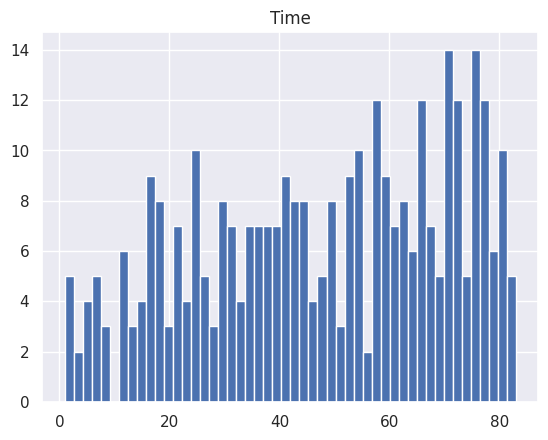

In [24]:
grouped_rc_times.hist('Time', bins=50)

array([[<Axes: title={'center': 'Time'}>]], dtype=object)

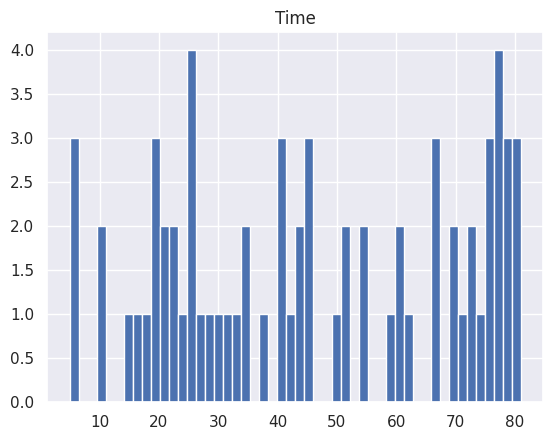

In [25]:
grouped_rc_times[grouped_rc_times['league_season'].isin(['2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016'])].hist('Time', bins=50)

<Axes: xlabel='count', ylabel='Time'>

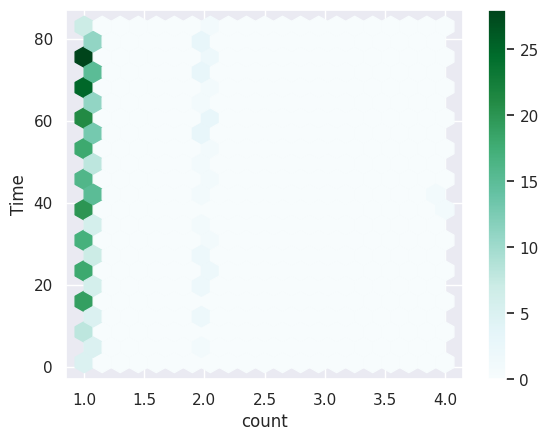

In [26]:
grouped_rc_times.plot.hexbin(x='count', y='Time', gridsize=20)

In [27]:
rc_game_total[['game_id', 'league_season']]

,game_id,league_season
1,167046,2012-2013
2,167039,2012-2013
3,167035,2012-2013
4,167027,2012-2013
5,167020,2012-2013
...,...,...
61,237369,2014-2015
62,237347,2014-2015
63,237373,2014-2015
64,237353,2014-2015


In [28]:
red_score.groupby(['league_season', 'league_id'])['home_points_after_home_red'].mean().reset_index()

,league_season,league_id,home_points_after_home_red
0,2011-2012,270559,9.000000
1,2012-2013,271937,15.000000
2,2013-2014,270557,11.500000
3,2013-2014,270559,10.000000
4,2013-2014,271937,15.000000
5,2014-2015,270557,5.800000
6,2014-2015,270559,16.166667
7,2015-2016,270559,9.375000
8,2015-2016,271937,8.500000
9,2016-2017,270557,4.333333


In [29]:
rc_game_total[rc_game_total['home_red_cards'] > 1]['game_id'].unique()

array([290260, 293195, 291420, 593247, 594162, 593669])

In [30]:
red_score[['league_season', 'game_id', 'home_points_after_home_red']].drop_duplicates()

,league_season,game_id,home_points_after_home_red
0,2023-2024,597957,0.0
1,2023-2024,597977,41.0
2,2023-2024,597976,9.0
3,2023-2024,597930,0.0
4,2021-2022,594370,13.0
...,...,...,...
167,2019-2020,295313,3.0
168,2019-2020,295330,0.0
169,2019-2020,295319,19.0
170,2019-2020,295351,10.0


In [31]:
league_red_score = red_score[
    red_score['game_id'].isin(rc_game_total[rc_game_total['home_red_cards'] >= 1]['game_id'].unique())
].groupby(['league_season', 'league_id'])[['home_points_after_home_red', 'home_points_after_away_red', 'away_points_after_home_red', 'away_points_after_away_red']].mean().reset_index()

league_red_score
# 

,league_season,league_id,home_points_after_home_red,home_points_after_away_red,away_points_after_home_red,away_points_after_away_red
0,2011-2012,270559,9.000000,7.5,7.666667,10.00
1,2012-2013,271937,15.000000,NaN,29.000000,NaN
2,2013-2014,270557,11.500000,3.0,10.500000,5.00
3,2013-2014,270559,10.000000,NaN,6.000000,NaN
4,2013-2014,271937,15.000000,NaN,17.000000,NaN
5,2014-2015,270557,5.800000,NaN,11.600000,NaN
6,2014-2015,270559,16.166667,NaN,17.500000,NaN
7,2015-2016,270559,9.375000,19.0,11.250000,20.00
8,2015-2016,271937,17.000000,NaN,7.000000,NaN
9,2016-2017,270557,4.333333,NaN,7.666667,NaN


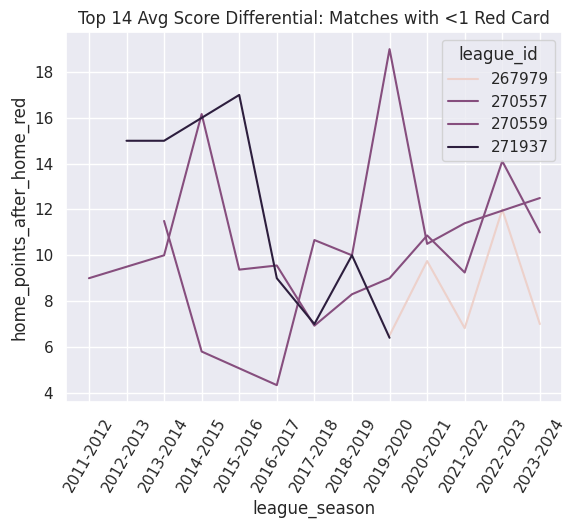

In [32]:
# fig, axes = plt.subplots(2,2, figsize=(10,2))

# color_codes = []
sns.lineplot(data=league_red_score, x='league_season', y='home_points_after_home_red', hue='league_id')


plt.title('Top 14 Avg Score Differential: Matches with <1 Red Card')
plt.xticks(rotation=60)
plt.show()

In [33]:
league_yellow_score = yellow_score[
    yellow_score['game_id'].isin(rc_game_total[rc_game_total['home_yellow_cards'] >= 1]['game_id'].unique())
].groupby(['league_season', 'league_id'])[['home_points_after_home_yellow', 'home_points_after_away_yellow']].mean().reset_index()

league_yellow_score


,league_season,league_id,home_points_after_home_yellow,home_points_after_away_yellow
0,2010-2011,270557,6.806452,12.210526
1,2010-2011,270559,12.000000,15.937500
2,2010-2011,271937,9.400000,21.000000
3,2011-2012,270557,9.062500,10.694444
4,2011-2012,270559,9.487500,14.116667
5,2011-2012,271937,11.619048,15.200000
6,2012-2013,270557,9.675000,11.571429
7,2012-2013,271937,8.615385,11.642857
8,2013-2014,270557,7.512821,9.636364
9,2013-2014,270559,8.272727,17.777778


<Axes: xlabel='league_season'>

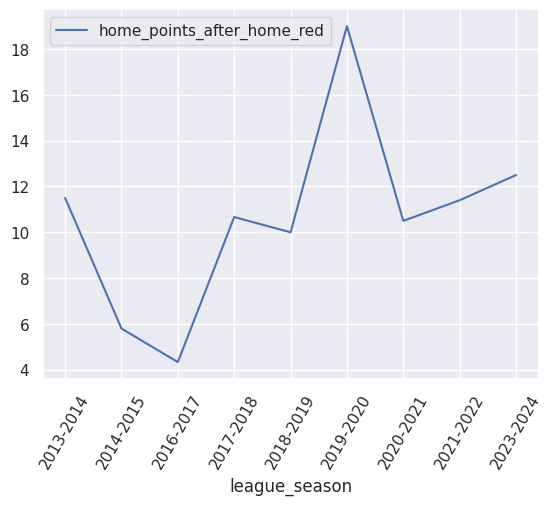

In [34]:
league_red_score[league_red_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_home_red', rot=60)


<Axes: xlabel='league_season'>

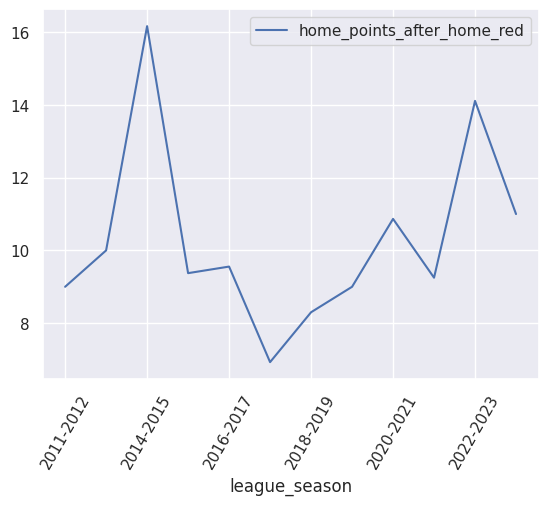

In [35]:
# yellow_score[
#     yellow_score['game_id'].isin(rc_game_total[rc_game_total['home_yellow_cards'] >= 1]['game_id'].unique())
# ].groupby('league_season')['away_points_after_home_yellow'].mean().plot(rot=60)

# yellow_score[
#     yellow_score['game_id'].isin(rc_game_total[rc_game_total['home_yellow_cards'] >= 1]['game_id'].unique())
# ].groupby('league_season')['home_points_after_home_yellow'].mean().plot(rot=60)

league_red_score[league_red_score['league_id'] == 270559].plot(x='league_season', y='home_points_after_home_red', rot=60)
# league_yellow_score[league_yellow_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_home_yellow', rot=60)

<Axes: xlabel='league_season'>

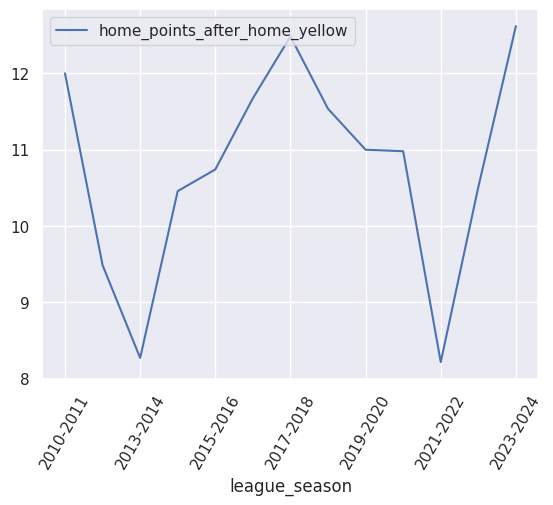

In [36]:
league_yellow_score[league_yellow_score['league_id'] == 270559].plot(x='league_season', y='home_points_after_home_yellow', rot=60)

<Axes: xlabel='league_season'>

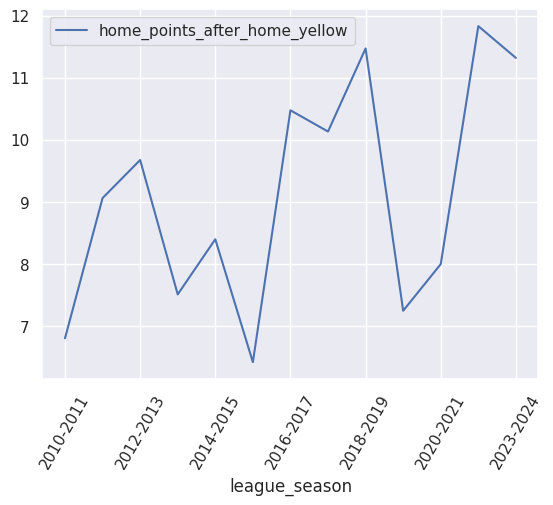

In [37]:
league_yellow_score[league_yellow_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_home_yellow', rot=60)

<Axes: xlabel='league_season'>

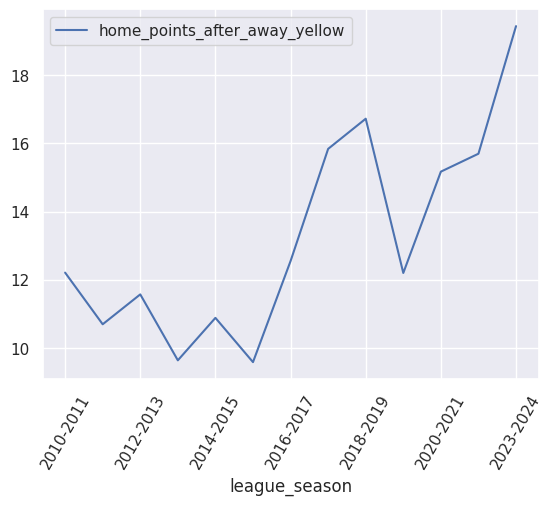

In [38]:
league_yellow_score[league_yellow_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_away_yellow', rot=60)

<Axes: xlabel='league_season'>

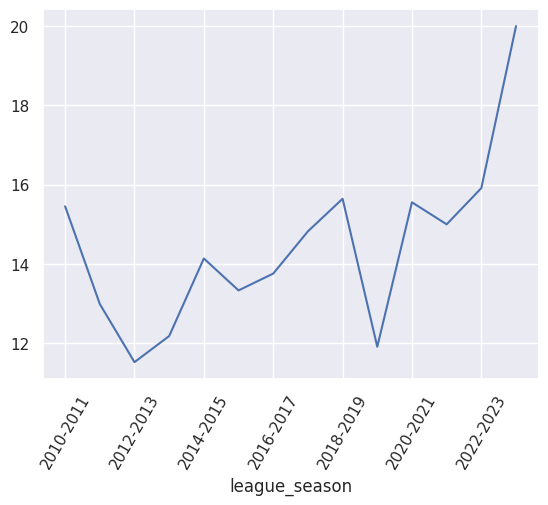

In [39]:
yellow_score[
    yellow_score['game_id'].isin(rc_game_total[rc_game_total['away_yellow_cards'] >= 1]['game_id'].unique())
].groupby('league_season')['home_points_after_away_yellow'].mean().plot(rot=60)

<Axes: xlabel='league_season'>

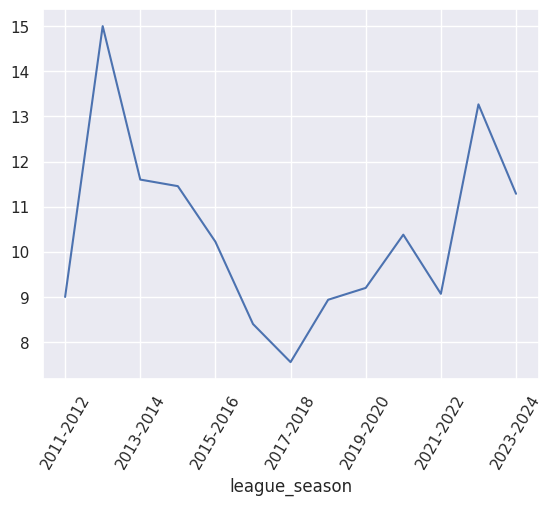

In [40]:
red_score[
    red_score['game_id'].isin(rc_game_total[rc_game_total['home_red_cards'] >= 1]['game_id'].unique())
].groupby('league_season')['home_points_after_home_red'].mean().plot(rot=60)

<Axes: xlabel='league_season'>

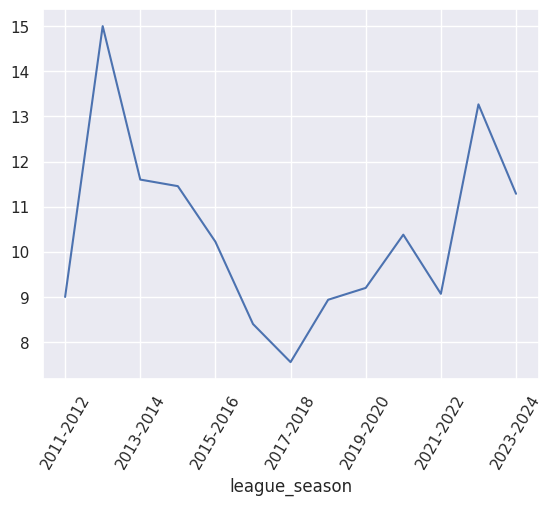

In [41]:
red_score[
    red_score['game_id'].isin(rc_game_total[rc_game_total['home_red_cards'] >= 1]['game_id'].unique())
].groupby('league_season')['home_points_after_home_red'].mean().plot(rot=60)

In [42]:
rc_game_p1_merge = rc_game_total.merge(
    rc_comm_filt[['game_id', 'Team','Time', 'Home_Score', 'Away_Score', 'first_card_flag']], 
    how='left', 
    left_on=['game_id', 'home_team'], 
    right_on=['game_id', 'Team'],
    suffixes=('', '_home')
)

rc_game_full_merge = rc_game_p1_merge.merge(
    rc_comm_filt[['game_id', 'Team','Time', 'Home_Score', 'Away_Score', 'first_card_flag']], 
    how='left', 
    left_on=['game_id', 'home_team'], 
    right_on=['game_id', 'Team']
)

In [43]:
rc_game_total

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,237369,271937,Montpellier Herault,27,Stade Toulousain,26,2.0,2.0,1.0,2.0,...,4.0,1.00,10.0,12.0,0.83,2015-01-25,2014-2015,Montpellier Herault,home,1
62,237347,271937,Glasgow Warriors,21,Montpellier Herault,10,3.0,1.0,3.0,1.0,...,7.0,0.71,12.0,13.0,0.92,2015-01-18,2014-2015,Glasgow Warriors,home,11
63,237373,271937,Northampton Saints,8,Racing 92,32,1.0,4.0,0.0,3.0,...,8.0,1.00,8.0,8.0,1.00,2015-01-24,2014-2015,Racing 92,away,24
64,237353,271937,Racing 92,53,Benetton Treviso,7,8.0,1.0,4.0,1.0,...,7.0,1.00,10.0,15.0,0.66,2015-01-18,2014-2015,Racing 92,home,46


In [44]:
test_join = comm_df.merge(first_card_df, on=['game_id', 'Team', 'Event_Type', 'Time'], how='left')
test_join.loc[test_join['first_card_flag'].isnull(), 'first_card_flag'] = 0
test_join

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597160,271937,82,Sale Sharks,Robert du Preez,Conversion,37.0,27.0,fourth_quarter,0.0
1,597160,271937,81,Sale Sharks,Tom Curtis,Try,37.0,25.0,fourth_quarter,0.0
2,597160,271937,80,Leinster,Charlie Ngatai,Sub_Out,37.0,20.0,fourth_quarter,0.0
3,597160,271937,80,Sale Sharks,Robert du Preez,Conversion,37.0,20.0,fourth_quarter,0.0
4,597160,271937,79,Sale Sharks,Tommy Taylor,Try,37.0,18.0,fourth_quarter,0.0
...,...,...,...,...,...,...,...,...,...,...
214991,290537,270557,30,Zebre,Derick Minnie,Try,13.0,7.0,first_half,0.0
214992,290537,270557,14,Zebre,Federico Ruzza,Try,8.0,7.0,first_half,0.0
214993,290537,270557,8,Dragons,Angus O'Brien,Conversion,3.0,7.0,first_half,0.0
214994,290537,270557,7,Dragons,Cory Hill,Try,3.0,5.0,first_half,0.0


In [45]:
test_join.groupby(['game_id'])['Time'].max().reset_index()

,game_id,Time
0,119090,79
1,119091,79
2,119092,74
3,119093,78
4,119094,72
...,...,...
4614,598223,79
4615,598224,81
4616,598225,78
4617,598226,80


In [46]:
test_join['first_card_flag'].value_counts()

first_card_flag
0.0    210377
1.0      4619
Name: count, dtype: int64

In [47]:
comm_grouped = comm_df.groupby(['game_id', 'Team', 'game_period', 'Event_Type'])['Player'].count().reset_index()

comm_grouped = get_match_time_metrics(comm_grouped, 'Red_Card', 'RC')
comm_grouped = get_match_time_metrics(comm_grouped, 'Yellow_Card', 'YC')
comm_grouped = get_match_time_metrics(comm_grouped, 'Try', 'Try')
comm_grouped = get_match_time_metrics(comm_grouped, 'Sub_In', 'Subs')

comm_cols = list(comm_grouped.columns)
comm_cols.remove('game_period')
comm_cols.remove('Event_Type')
comm_cols.remove('Player')

comm_final = comm_grouped.groupby(['game_id', 'Team'])[[i for i in comm_cols if i not in ['game_id', 'Team']]].sum().reset_index()


In [48]:
total_club_df.columns

Index(['game_id', 'league_id', 'home_team', 'home_team_score', 'away_team',
       'away_team_score', 'home_tries', 'away_tries', 'home_conversions',
       'away_conversions', 'home_penalty_goals', 'away_penalty_goals',
       'home_kick_percent', 'away_kick_percent', 'home_total_meters',
       'away_total_meters', 'home_kfh', 'away_kfh', 'home_pass_meters',
       'away_pass_meters', 'home_runs', 'away_runs', 'home_possession_1h_2h',
       'home_territory_1h_2h', 'home_clean_breaks', 'home_defenders_beaten',
       'home_offloads', 'home_rucks_won', 'home_mauls_won',
       'home_turnovers_conceeded', 'away_possession_1h_2h',
       'away_territory_1h_2h', 'away_clean_breaks', 'away_defenders_beaten',
       'away_offloads', 'away_rucks_won', 'away_mauls_won',
       'away_turnovers_conceeded', 'home_total_possession',
       'home_total_territory', 'away_total_possesion', 'away_total_territory',
       'home_scrum', 'home_lineout', 'away_scrum', 'away_lineout',
       'home_tackle

In [218]:
total_club_df['home_turnovers_conceeded']

0     17.0
1      7.0
2     12.0
3     15.0
4     15.0
      ... 
62    18.0
63    17.0
64    14.0
65    20.0
66     7.0
Name: home_turnovers_conceeded, Length: 6231, dtype: float64

In [ ]:
away_tackles_perc

In [58]:
total_club_df['home_rucks_won']

0     142 / 149 (95%)
1       51 / 53 (96%)
2     138 / 142 (97%)
3       65 / 70 (92%)
4       96 / 98 (97%)
           ...       
62      73 / 80 (91%)
63      55 / 57 (96%)
64     81 / 81 (100%)
65      88 / 95 (92%)
66      74 / 78 (94%)
Name: home_rucks_won, Length: 6231, dtype: object

In [53]:
total_club_df['home_rucks_won_num']/total_club_df['home_rucks_won_total_num']

0     0.953020
1     0.962264
2     0.971831
3     0.928571
4     0.979592
        ...   
62    0.912500
63    0.964912
64    1.000000
65    0.926316
66    0.948718
Length: 6231, dtype: float64

In [219]:
club_vars = total_club_df[
    [
        'game_id', 'league_id', 
        'home_team', 'away_team', 
        'home_red_cards', 'home_yellow_cards', 
        'away_red_cards', 'away_yellow_cards', 
        'winning_team', 'winning_side', 'season',
        'home_total_possession', 'away_total_possesion',
        'home_total_territory', 'away_total_territory',
        'home_rucks_won_num', 'away_rucks_won_num', 
        'home_scrum_num', 'away_scrum_num',
        'home_tackle_perc', 'away_tackle_perc',
        'home_clean_breaks', 'away_clean_breaks',
        'home_turnovers_conceeded', 'away_turnovers_conceeded'
    ]
].merge(
    comb_team_info[['team_name', 'team_id', 'rank', 'season']],
    how='left',
    left_on=['home_team', 'season'],
    right_on=['team_name', 'season'],
    suffixes=('', '_home')
).merge(
    comb_team_info[['team_name', 'team_id', 'rank', 'season']],
    how='left',
    left_on=['away_team', 'season'],
    right_on=['team_name', 'season'],
    suffixes=('', '_away')
)

# Attach the match commentary data to the Club Variables data 

club_vars = club_vars.merge(
    comm_final,
    left_on=['game_id', 'home_team'],
    right_on=['game_id', 'Team'],
    how='left',
    suffixes=('', '_home')
).merge(
    comm_final,
    left_on=['game_id', 'away_team'],
    right_on=['game_id', 'Team'],
    how='left',
    suffixes=('', '_away')
)

club_vars



,game_id,league_id,home_team,away_team,home_red_cards,home_yellow_cards,away_red_cards,away_yellow_cards,winning_team,winning_side,...,H1_RC_away,Last_20_YC_away,Q3_YC_away,H1_YC_away,Last_20_Try_away,Q3_Try_away,H1_Try_away,Last_20_Subs_away,Q3_Subs_away,H1_Subs_away
0,167053,270557,Leinster,Connacht,0.0,0.0,0.0,0.0,Leinster,home,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0
1,167046,270557,Ulster,Leinster,0.0,1.0,0.0,0.0,Ulster,home,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,0.0
2,167039,270557,Leinster,Zebre,0.0,0.0,0.0,1.0,Leinster,home,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,4.0,0.0
3,167035,270557,Glasgow Warriors,Leinster,0.0,2.0,0.0,1.0,Leinster,away,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0
4,167027,270557,Ospreys,Leinster,0.0,1.0,0.0,0.0,Ospreys,home,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6226,237347,271937,Glasgow Warriors,Montpellier Herault,0.0,0.0,0.0,2.0,Glasgow Warriors,home,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.0,2.0,1.0
6227,237373,271937,Northampton Saints,Racing 92,0.0,1.0,0.0,1.0,Racing 92,away,...,0.0,0.0,1.0,0.0,1.0,3.0,0.0,6.0,2.0,0.0
6228,237353,271937,Racing 92,Benetton Treviso,0.0,0.0,0.0,1.0,Racing 92,home,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,3.0,0.0
6229,237351,271937,Ospreys,Northampton Saints,0.0,0.0,0.0,1.0,Northampton Saints,away,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,3.0,1.0,1.0


In [62]:
club_vars['home_rucks_won_num'] #.str[:-1].astype(int) * 0.01

0       142.0
1        51.0
2       138.0
3        65.0
4        96.0
        ...  
6226     73.0
6227     55.0
6228     81.0
6229     88.0
6230     74.0
Name: home_rucks_won_num, Length: 6231, dtype: float64

In [220]:
def season_binning(season):
    bin_val = None
    if season < 2017:
        bin_val = 0
    else:
        bin_val = 1
    return bin_val

club_vars.loc[club_vars['home_tackle_perc'] == 'NaN%', 'home_tackle_perc'] = '0%'
club_vars.loc[club_vars['away_tackle_perc'] == 'NaN%', 'away_tackle_perc'] = '0%'

game_df_use = club_vars.loc[:, ~club_vars.columns.duplicated()]
game_df_use = game_df_use[game_df_use['winning_side'] != 'Tie'].reset_index(drop=True)
game_df_use["rank"] = game_df_use.sort_values(["home_team", "season"]).groupby("home_team")["rank"].ffill().bfill()
game_df_use["rank_away"] = game_df_use.sort_values(["away_team", "season"]).groupby("away_team")["rank_away"].ffill().bfill()

game_df_use['home_total_possession'] = game_df_use['home_total_possession'].str[:-1].astype(int) * 0.01
game_df_use['away_total_possession'] = game_df_use['away_total_possesion'].str[:-1].astype(int) * 0.01

game_df_use['home_total_territory'] = game_df_use['home_total_territory'].str[:-1].astype(int) * 0.01
game_df_use['away_total_territory'] = game_df_use['away_total_territory'].str[:-1].astype(int) * 0.01

game_df_use['home_tackle_perc'] = game_df_use['home_tackle_perc'].str[:-1].astype(int) * 0.01
game_df_use['away_tackle_perc'] = game_df_use['away_tackle_perc'].str[:-1].astype(int) * 0.01

game_df_use['season_bin'] = game_df_use['season'].apply(season_binning)
game_df_use['rc_season_interact'] = game_df_use['home_red_cards'] * game_df_use['season_bin']
game_df_use['home_rank_diff'] = game_df_use['rank'] - game_df_use['rank_away']


game_df_use['home_red_cards_centered'] = game_df_use['home_red_cards'] - game_df_use['home_red_cards'].mean()
game_df_use['season_bin_centered'] = game_df_use['season_bin'] - game_df_use['season_bin'].mean()

game_df_use['rc_season_interact_centered'] = game_df_use['home_red_cards_centered'] * game_df_use['season_bin_centered']

In [134]:
game_df_use.columns

Index(['game_id', 'league_id', 'home_team', 'away_team', 'home_red_cards',
       'home_yellow_cards', 'away_red_cards', 'away_yellow_cards',
       'winning_team', 'winning_side', 'season', 'home_total_possession',
       'away_total_possesion', 'home_total_territory', 'away_total_territory',
       'team_name', 'team_id', 'rank', 'team_name_away', 'team_id_away',
       'rank_away', 'Team', 'Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC',
       'Q3_YC', 'H1_YC', 'Last_20_Try', 'Q3_Try', 'H1_Try', 'Last_20_Subs',
       'Q3_Subs', 'H1_Subs', 'Team_away', 'Last_20_RC_away', 'Q3_RC_away',
       'H1_RC_away', 'Last_20_YC_away', 'Q3_YC_away', 'H1_YC_away',
       'Last_20_Try_away', 'Q3_Try_away', 'H1_Try_away', 'Last_20_Subs_away',
       'Q3_Subs_away', 'H1_Subs_away', 'away_total_possession', 'season_bin',
       'rc_season_interact', 'home_rank_diff'],
      dtype='object')

In [221]:
match_time_metrics = [
    'Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
    'Last_20_Try', 'Q3_Try', 'H1_Try', 'Last_20_Subs', 'Q3_Subs', 'H1_Subs',
    'Last_20_RC_away', 'Q3_RC_away', 'H1_RC_away', 'season',
    'Last_20_YC_away', 'Q3_YC_away', 'H1_YC_away', 'Last_20_Try_away',
    'Q3_Try_away', 'H1_Try_away', 'Last_20_Subs_away', 'Q3_Subs_away',
    'H1_Subs_away', 'away_red_cards', 'away_yellow_cards', 'season_bin', 'rc_season_interact',
    'home_rank_diff', 'home_red_cards', 'home_yellow_cards', 'home_total_possession', 
    'away_total_possession', 'home_total_territory', 'away_total_territory',
    'home_tackle_perc', 'away_tackle_perc', 
    'home_rucks_won_num', 'away_rucks_won_num', 
    'home_scrum_num', 'away_scrum_num',
    'home_clean_breaks', 'away_clean_breaks',
    'home_red_cards_centered', 'season_bin_centered', 'rc_season_interact_centered',
    'home_turnovers_conceeded', 'away_turnovers_conceeded'
]

rank_metrics = ['rank', 'rank_away']

id_feats = ['game_id', 'league_id']

# game_df_use = game_df_use[(~game_df_use['Last_20_RC'].isnull()) & (~game_df_use['away_red_cards'].isnull())].reset_index(drop=True)
game_df_use = game_df_use[game_df_use['home_total_possession'] > 0]


game_x_df = game_df_use[
    ['game_id', 'league_id'] + rank_metrics + match_time_metrics 
]
game_y_df = game_df_use[['game_id', 'winning_side']]


game_y_df.loc[game_y_df['winning_side'] == 'home', 'target'] = 1
game_y_df.loc[game_y_df['winning_side'] == 'away', 'target'] = 0
game_y_df['target'].value_counts()

x_df_dummy = pd.get_dummies(game_x_df, columns=['league_id'])

/tmp/ipykernel_583049/1000987191.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_y_df.loc[game_y_df['winning_side'] == 'home', 'target'] = 1


In [79]:
x_df_dummy[['home_total_possession', 
    'away_total_possession', 'home_total_territory', 'away_total_territory',]]

,home_total_possession,away_total_possession,home_total_territory,away_total_territory
0,1.00,0.00,0.00,0.00
1,0.75,0.25,0.00,0.00
2,0.83,0.17,0.00,0.00
3,0.00,0.00,0.00,0.00
4,0.50,0.50,0.00,0.00
...,...,...,...,...
4449,0.59,0.41,0.63,0.37
4450,0.36,0.64,0.35,0.65
4451,0.68,0.32,0.76,0.24
4452,0.51,0.49,0.53,0.47


In [136]:
x_df_dummy

,game_id,rank,rank_away,Last_20_RC,Q3_RC,H1_RC,Last_20_YC,Q3_YC,H1_YC,Last_20_Try,...,home_tackle_perc,away_tackle_perc,home_rucks_won_num,away_rucks_won_num,home_scrum_num,away_scrum_num,league_id_267979,league_id_270557,league_id_270559,league_id_271937
0,167053,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.91,0.91,142.0,49.0,9.0,13.0,False,True,False,False
1,167046,6.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.92,0.96,51.0,102.0,10.0,2.0,False,True,False,False
2,167039,1.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.84,0.88,138.0,54.0,8.0,7.0,False,True,False,False
3,167035,4.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.94,0.98,65.0,71.0,14.0,7.0,False,True,False,False
4,167027,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.86,0.91,96.0,115.0,4.0,6.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,237347,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.87,0.82,73.0,54.0,7.0,5.0,False,False,False,True
4450,237373,1.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.85,0.79,55.0,105.0,7.0,8.0,False,False,False,True
4451,237353,5.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.83,0.73,81.0,28.0,3.0,7.0,False,False,False,True
4452,237351,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.84,0.85,88.0,83.0,4.0,7.0,False,False,False,True


In [139]:
model_input['home_total_possession'].min()

np.float64(0.0)

In [229]:
model_input = x_df_dummy[[
    # 'rc_season_interact',
    'home_red_cards_centered', 'season_bin_centered', 
    'rc_season_interact_centered',
    # 'Last_20_RC', 'Q3_RC', 'H1_RC', 
    # 'Last_20_YC', 'Q3_YC', 'H1_YC', 
    # 'home_red_cards', 
    'home_yellow_cards',
    'away_red_cards', 
    'away_yellow_cards', 
    # 'season_bin',
    # 'season',
    # 'rank', 
    # 'rank_away', 
    'home_total_possession', 
    # 'away_total_possession', 
    'home_total_territory', 
    # 'away_total_territory',
    'home_tackle_perc', 
    # 'away_tackle_perc', 
    'home_rucks_won_num', 
    # 'away_rucks_won_num', 
    'home_scrum_num', 
    # 'away_scrum_num',
    'home_clean_breaks', 
    # 'away_clean_breaks',
    'league_id_267979', 'league_id_270557', 'league_id_270559', 'league_id_271937',
    'home_rank_diff',
    'home_turnovers_conceeded',
    'away_turnovers_conceeded'
    ]
]

# model_input = model_input[model_input['home_total_possession'] > 0]
# model_input.fillna(0.0, inplace=True)
# x_train, x_test, y_train, y_test = train_test_split(model_input, game_y_df['target'], stratify=model_input['season'], random_state=4, test_size=0.2)

log_reg = LogisticRegression(
    solver='newton-cholesky', 
                             random_state=10)
log_reg.fit(
    model_input,
    game_y_df['target']
#     x_train, y_train
)




LogisticRegression(random_state=10, solver='newton-cholesky')

In [118]:
log_reg.coef_

array([[-0.12427394, -0.18683261,  0.44337126,  0.06669079, -0.19330718,
         0.18477508,  2.93054464, -0.25836983,  0.01460093, -0.01703888,
         0.00816409,  0.08054645, -0.12588588, -0.22978125, -0.116603  ,
         0.39989513, -0.05351088]])

In [230]:
model_input.corr()

,home_red_cards_centered,season_bin_centered,rc_season_interact_centered,home_yellow_cards,away_red_cards,away_yellow_cards,home_total_possession,home_total_territory,home_tackle_perc,home_rucks_won_num,home_scrum_num,home_clean_breaks,league_id_267979,league_id_270557,league_id_270559,league_id_271937,home_rank_diff,home_turnovers_conceeded,away_turnovers_conceeded
home_red_cards_centered,1.000000,0.056371,0.370098,-0.000621,0.096524,0.027396,-0.034050,0.011120,-0.019324,-0.000902,-0.001826,-0.036365,-0.000788,-0.036877,0.058777,-0.031379,0.031126,-0.039766,0.002035
season_bin_centered,0.056371,1.000000,-0.001648,0.017444,0.069768,-0.039711,-0.216644,0.459060,0.031532,0.205804,-0.032999,0.098995,0.005619,-0.050720,0.134708,-0.128330,0.016948,-0.006788,0.020507
rc_season_interact_centered,0.370098,-0.001648,1.000000,-0.010540,-0.001009,-0.005548,0.026703,-0.014219,0.004690,-0.011462,0.002723,-0.013572,-0.010619,0.007153,0.007012,-0.004843,-0.000629,0.000128,-0.015465
home_yellow_cards,-0.000621,0.017444,-0.010540,1.000000,0.056853,0.107461,-0.070960,-0.074846,-0.011008,-0.155543,-0.056127,-0.052147,-0.030412,-0.060989,0.094092,-0.006992,0.087162,-0.087815,-0.017416
away_red_cards,0.096524,0.069768,-0.001009,0.056853,1.000000,0.011828,0.005063,0.018600,0.017951,-0.017023,-0.021552,0.053910,-0.006462,-0.018451,0.042920,-0.026278,-0.024491,0.023268,-0.039978
away_yellow_cards,0.027396,-0.039711,-0.005548,0.107461,0.011828,1.000000,0.116134,-0.058528,-0.028349,-0.022661,0.049962,0.033703,-0.082887,-0.046754,0.167891,-0.057260,-0.077632,-0.009924,-0.094871
home_total_possession,-0.034050,-0.216644,0.026703,-0.070960,0.005063,0.116134,1.000000,-0.252048,0.008789,0.114300,0.115512,0.148668,-0.067824,-0.016701,0.148986,-0.092583,-0.283208,-0.011553,0.031975
home_total_territory,0.011120,0.459060,-0.014219,-0.074846,0.018600,-0.058528,-0.252048,1.000000,0.066429,0.300408,0.009326,0.034458,0.074759,0.046006,-0.302036,0.258462,-0.006144,0.088719,0.026472
home_tackle_perc,-0.019324,0.031532,0.004690,-0.011008,0.017951,-0.028349,0.008789,0.066429,1.000000,0.338182,0.243680,0.170882,0.056997,0.007648,-0.103982,0.056636,-0.028765,0.297104,0.285014
home_rucks_won_num,-0.000902,0.205804,-0.011462,-0.155543,-0.017023,-0.022661,0.114300,0.300408,0.338182,1.000000,0.054851,0.209941,0.041462,0.094307,-0.154996,0.031934,-0.060472,0.216322,0.067220


Brier Score: 0.1359347433152249
AUC Score: 0.863203216052466


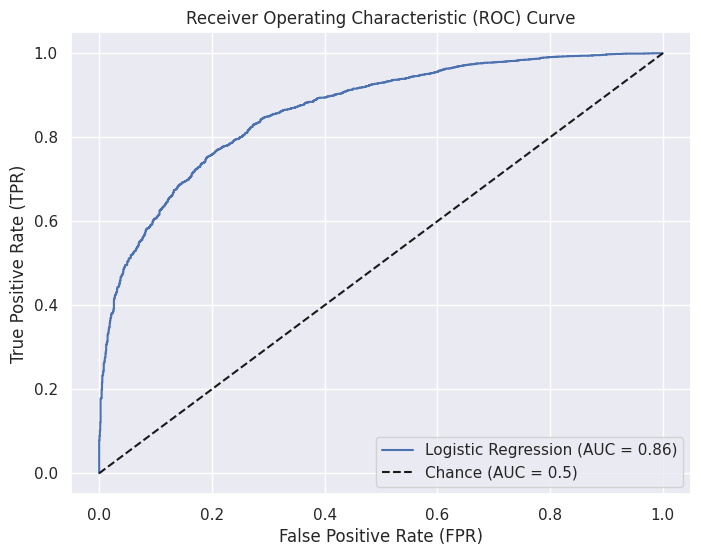

In [231]:
test_output = log_reg.predict_proba(model_input)

b_score = brier_score_loss(game_y_df['target'], test_output[:,1:])
auc = roc_auc_score(game_y_df['target'], test_output[:,1:])
fpr, tpr, thresholds = roc_curve(game_y_df['target'], test_output[:,1:])
print(f"Brier Score: {b_score}")
print(f"AUC Score: {auc}")

plt.figure(figsize=(8, 6))
# Plot the ROC curve with AUC label
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
# Plot the random chance line (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [232]:
from sklearn.metrics import log_loss 

log_score = log_loss(game_y_df['target'], test_output)
log_score

0.41828321567244225

In [233]:
bool_cols = model_input.select_dtypes(include=[bool])
model_input[bool_cols.columns] = bool_cols.astype(int)

/tmp/ipykernel_583049/1258602473.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_input[bool_cols.columns] = bool_cols.astype(int)


In [209]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [234]:
test_vif = model_input.copy()
test_vif['constant'] = 1

vif_df = pd.DataFrame()

vif_df["feature"] = test_vif.columns
vif_df["VIF"] = [variance_inflation_factor(test_vif.values, i) for i in range(test_vif.shape[1])]

print(vif_df)



                        feature       VIF
0       home_red_cards_centered  1.188906
1           season_bin_centered  1.629263
2   rc_season_interact_centered  1.166788
3             home_yellow_cards  1.069679
4                away_red_cards  1.029496
5             away_yellow_cards  1.083679
6         home_total_possession  1.318205
7          home_total_territory  1.803081
8              home_tackle_perc  1.328152
9            home_rucks_won_num  1.406968
10               home_scrum_num  1.293147
11            home_clean_breaks  1.180298
12             league_id_267979       inf
13             league_id_270557       inf
14             league_id_270559       inf
15             league_id_271937       inf
16               home_rank_diff  1.156450
17     home_turnovers_conceeded  1.203273
18     away_turnovers_conceeded  1.371503
19                     constant  0.000000


/home/colingrosh/anaconda3/envs/sports_env/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/colingrosh/anaconda3/envs/sports_env/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [235]:
# Add a constant (intercept) term to the features, which statsmodels requires
X_with_constant = sm.add_constant(np.asarray(model_input))

# Create and fit the statsmodels GLM model (Logistic Regression with Binomial family)
# The Logit class is also a valid option
# model_sm = sm.GLM(np.asarray(game_y_df['target']), X_with_constant, family=sm.families.Binomial())
model_sm = sm.Logit(np.asarray(game_y_df['target']), X_with_constant)
results = model_sm.fit()

# Print the summary
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.417912
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 5134
Model:                          Logit   Df Residuals:                     5115
Method:                           MLE   Df Model:                           18
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.3277
Time:                        17:28:59   Log-Likelihood:                -2145.6
converged:                       True   LL-Null:                       -3191.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7845   2.55e+06  -6.99e-07      1.000      -5e+06       5e+06
x1            -0.3528      0.

In [161]:
model_input.columns[15]

'away_total_territory'

In [177]:
model_input.columns

Index(['rc_season_interact', 'home_yellow_cards', 'away_red_cards',
       'away_yellow_cards', 'rank', 'rank_away', 'home_total_possession',
       'home_total_territory', 'away_total_territory', 'league_id_267979',
       'league_id_270557', 'league_id_270559', 'league_id_271937'],
      dtype='object')

In [107]:
X_with_constant.shape

(4454, 17)

In [33]:
model_preds.reshape(-1,1)

array([[0.87746107],
       [0.47324989],
       [0.94110482],
       ...,
       [0.61749029],
       [0.68220446],
       [0.70017773]])

In [64]:
model_preds = results.predict(X_with_constant).reshape(-1,1)
brier_score_loss(game_y_df['target'], model_preds)

np.float64(0.1789015682181444)

In [66]:
model_input.columns

Index(['Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
       'away_red_cards', 'away_yellow_cards', 'season', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559'],
      dtype='object')

In [54]:
model_input.columns[2]

'H1_RC'

In [53]:
results.pvalues[2]

np.float64(0.08314725396314772)

In [42]:
results.pvalues.argsort()

array([10, 11,  7,  5,  6,  2,  8,  3,  4, 14,  0, 13,  9, 12,  1])

In [63]:
results.params

array([ 1.01129212e+01, -1.26476774e-01, -5.55730652e-01, -3.28713345e-01,
        8.10351098e-02, -2.67778454e-01, -2.41403484e-01,  5.43383410e-01,
        8.48916349e-02, -6.26070175e-03, -1.80118424e-01,  1.79449937e-01,
        3.14855835e+00,  3.19673356e+00,  3.76762925e+00])

In [65]:
dir(results)[85:]

['remove_data',
 'resid_anscombe',
 'resid_anscombe_scaled',
 'resid_anscombe_unscaled',
 'resid_deviance',
 'resid_pearson',
 'resid_response',
 'resid_working',
 'save',
 'scale',
 'score_test',
 'summary',
 'summary2',
 't_test',
 't_test_pairwise',
 'tvalues',
 'use_t',
 'wald_test',
 'wald_test_terms']

In [35]:
model_input.columns

Index(['Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
       'away_red_cards', 'away_yellow_cards', 'season', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559'],
      dtype='object')

In [37]:
test_output = log_reg.predict_proba(x_test)

In [40]:
test_output[:,1:]

array([[0.77097908],
       [0.58326901],
       [0.80892903],
       [0.7550711 ],
       [0.93272385],
       [0.76478775],
       [0.26932788],
       [0.64056608],
       [0.85020252],
       [0.64864759],
       [0.75534779],
       [0.87158786],
       [0.90661992],
       [0.68128565],
       [0.25552734],
       [0.83423674],
       [0.67261006],
       [0.76932459],
       [0.64952667],
       [0.59406769],
       [0.49860401],
       [0.49050412],
       [0.85748489],
       [0.43468734],
       [0.6484242 ],
       [0.45140889],
       [0.64924039],
       [0.8795317 ],
       [0.58491511],
       [0.57351322],
       [0.66838258],
       [0.60033626],
       [0.53921179],
       [0.27812863],
       [0.67122561],
       [0.66997979],
       [0.63301109],
       [0.66707392],
       [0.79830772],
       [0.92852244],
       [0.74122752],
       [0.87020067],
       [0.315037  ],
       [0.71841129],
       [0.38209429],
       [0.89379533],
       [0.62911559],
       [0.518

In [ ]:
x_train

,Last_20_RC,Q3_RC,H1_RC,Last_20_YC,Q3_YC,H1_YC,away_red_cards,away_yellow_cards,season,rank,rank_away,league_id_267979,league_id_270557,league_id_270559
2364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2017,9.0,3.0,False,False,True
3741,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2021,9.0,12.0,True,False,False
3608,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2020,8.0,2.0,True,False,False
1411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2016,8.0,9.0,False,True,False
3518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,7.0,10.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021,10.0,4.0,True,False,False
2713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2022,9.0,1.0,False,False,True
352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,1.0,6.0,False,True,False
1589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016,1.0,10.0,False,False,True


In [ ]:
x_train.columns

Index(['Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
       'away_red_cards', 'away_yellow_cards', 'season', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559'],
      dtype='object')

In [ ]:
log_reg.coef_

array([[-3.63085183e-02, -1.81298049e-01, -2.15971839e-01,
         1.59424529e-01, -3.81584098e-01, -1.89106247e-01,
         4.31932717e-01,  7.96633048e-02,  3.60915584e-04,
        -1.63466557e-01,  1.72269575e-01, -3.48927148e-01,
        -8.79662996e-02,  4.38468349e-01]])

In [ ]:
x_train.columns[5]

'H1_YC'

In [ ]:
log_reg.coef_[0][5]

np.float64(-0.18910624727914008)

np.float64(0.17047917744081964)

In [ ]:
test_output = log_reg.predict_proba(x_test)

brier_score_loss(y_test, test_output[:,1:])
auc = roc_auc_score(y_test, test_output[:,1:])
fpr, tpr, thresholds = roc_curve(y_test, test_output[:,1:])


plt.figure(figsize=(8, 6))
# Plot the ROC curve with AUC label
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
# Plot the random chance line (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


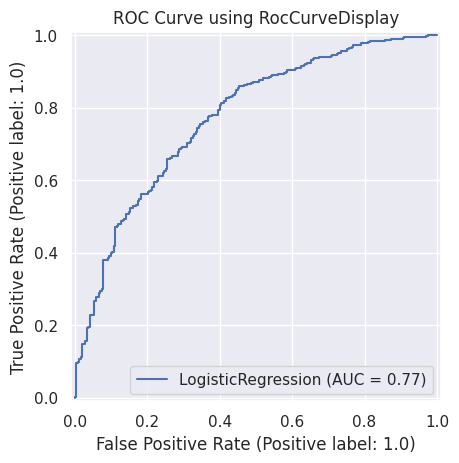

In [ ]:
RocCurveDisplay.from_estimator(log_reg, x_test, y_test)
plt.title('ROC Curve using RocCurveDisplay')
plt.show()

In [ ]:
test_output

array([[0.12452696, 0.87547304],
       [0.52367099, 0.47632901],
       [0.05989088, 0.94010912],
       ...,
       [0.38832893, 0.61167107],
       [0.32421274, 0.67578726],
       [0.30573152, 0.69426848]])

In [ ]:
test_output[:,1:]

array([[0.87547304],
       [0.47632901],
       [0.94010912],
       ...,
       [0.61167107],
       [0.67578726],
       [0.69426848]])

In [ ]:
game_y_df

,game_id,winning_side,target
0,167053,home,1.0
1,167046,home,1.0
2,167039,home,1.0
3,167035,away,0.0
4,167027,home,1.0
...,...,...,...
4057,597121,away,0.0
4058,597107,home,1.0
4059,597112,away,0.0
4060,597108,away,0.0


In [ ]:
log_reg.predict_proba(model_input)

array([[0.12651334, 0.87348666],
       [0.60457919, 0.39542081],
       [0.05969532, 0.94030468],
       ...,
       [0.365974  , 0.634026  ],
       [0.30315796, 0.69684204],
       [0.28491123, 0.71508877]])